# CAY Replication Tour

This notebook inspects the processed quarterly panel and generated report artifacts. It does not reacquire data or reimplement the estimation pipeline.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "reports" / "report_contract.yml").exists():
            return candidate
    raise FileNotFoundError("Could not locate reports/report_contract.yml from the notebook path.")


ROOT = find_repository_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "_data" / "processed" / "core_quarterly.parquet"
CAY_PATH = ROOT / "reports" / "build" / "current_vintage_cay_comparison.csv"
AUDIT_PATH = ROOT / "reports" / "tables" / "table_r1_replication_audit.csv"
METADATA_PATH = ROOT / "reports" / "build" / "report_metadata.json"

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing processed panel: {PANEL_PATH}. Run `python -m src.pipeline panel`.")
if not CAY_PATH.exists():
    raise FileNotFoundError(f"Missing CAY comparison: {CAY_PATH}. Run `python -m src.pipeline exhibits`.")

panel = pd.read_parquet(PANEL_PATH)
if not isinstance(panel.index, pd.PeriodIndex):
    panel.index = pd.PeriodIndex(panel.index, freq="Q")
panel = panel.sort_index()

cay_comparison = pd.read_csv(CAY_PATH, index_col=0)
if "cay_current_vintage" not in cay_comparison:
    raise ValueError(f"CAY comparison lacks cay_current_vintage: {CAY_PATH}")
cay_comparison.index = pd.PeriodIndex(cay_comparison.index, freq="Q")
panel["cay"] = cay_comparison["cay_current_vintage"]

print(f"Repository: {ROOT}")
print(f"Panel: {panel.index.min()} through {panel.index.max()} ({len(panel)} quarters)")

Repository: /Users/zhichengzhou/Google Drive/UChicago/FINM329/hw/Study_of_Cay_and_Predictivity_Lab
Panel: 1871Q1 through 2026Q2 (622 quarters)


## Coverage

Inspect the first and last observed quarter and missing counts for the macro levels, independently estimated CAY, and both excess-return series.

In [3]:
if "cay" not in panel.columns and {"c", "a", "y"}.issubset(panel.columns):
    panel = panel.copy()
    panel["cay"] = panel["c"] - 0.31 * panel["a"] - 0.59 * panel["y"]

coverage_columns = ["c", "a", "y", "cay", "sp_excess_return", "crsp_vw_excess_return"]
missing_columns = sorted(set(coverage_columns) - set(panel.columns))
if missing_columns:
    raise ValueError(f"Processed panel lacks notebook columns: {missing_columns}. Run `python -m src.pipeline exhibits`.")

coverage = pd.DataFrame(
    {
        "first_quarter": [str(panel[column].first_valid_index()) for column in coverage_columns],
        "last_quarter": [str(panel[column].last_valid_index()) for column in coverage_columns],
        "observations": [int(panel[column].count()) for column in coverage_columns],
        "missing": [int(panel[column].isna().sum()) for column in coverage_columns],
    },
    index=coverage_columns,
)
coverage

,first_quarter,last_quarter,observations,missing
c,1952Q4,2026Q2,295,327
a,1952Q4,2026Q1,294,328
y,1952Q4,2026Q2,295,327
cay,1952Q4,1998Q3,184,438
sp_excess_return,1926Q1,2023Q2,390,232
crsp_vw_excess_return,1926Q1,2024Q4,396,226


## Summary Statistics

The table reports sample size, moments, percentiles, and first-order autocorrelation from the processed panel.

In [4]:
summary_rows = []
for column in coverage_columns:
    series = panel[column].dropna()
    summary_rows.append(
        {
            "variable": column,
            "observations": len(series),
            "mean": series.mean(),
            "standard_deviation": series.std(ddof=1),
            "p05": series.quantile(0.05),
            "median": series.median(),
            "p95": series.quantile(0.95),
            "ar1": series.corr(series.shift(1)),
        }
    )
summary = pd.DataFrame(summary_rows).set_index("variable")
summary

,observations,mean,standard_deviation,p05,median,p95,ar1
variable,,,,,,,
c,295,-3.424002,0.396351,-4.070641,-3.399465,-2.849050,0.999676
a,294,5.326309,0.483588,4.656235,5.279257,6.173718,0.999287
y,295,3.301627,0.372979,2.664626,3.309678,3.843745,0.998969
cay,184,-7.552948,0.018204,-7.586870,-7.549791,-7.525103,0.899012
sp_excess_return,390,0.016256,0.096006,-0.138501,0.026668,0.124284,-0.045445
crsp_vw_excess_return,396,0.015670,0.104057,-0.165880,0.031123,0.140130,-0.037315


## Data Anatomy

The first panel indexes real per-capita macro levels to 100 at their first common observation. The second standardizes CAY and S&P excess returns over their displayed common sample.

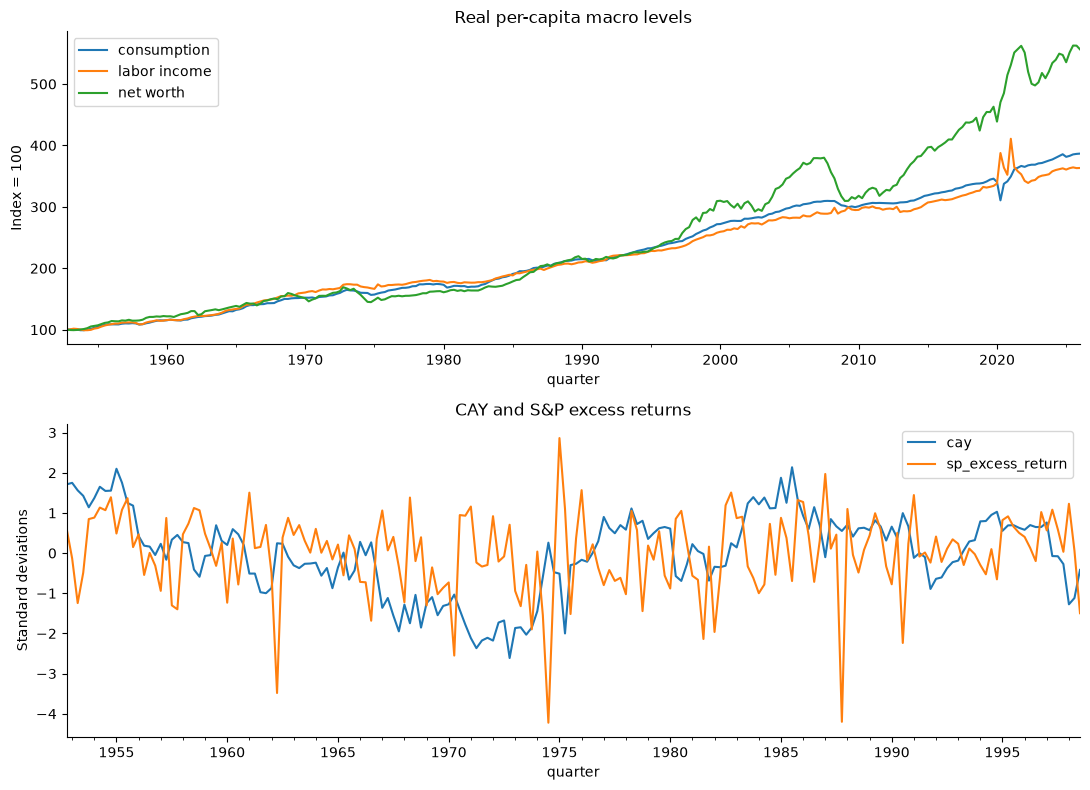

In [5]:
macro = panel[["c", "y", "a"]].dropna()
indexed = 100 * np.exp(macro - macro.iloc[0])
descriptive = panel[["cay", "sp_excess_return"]].dropna()
standardized = (descriptive - descriptive.mean()) / descriptive.std(ddof=1)

figure, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
indexed.rename(columns={"c": "consumption", "y": "labor income", "a": "net worth"}).plot(ax=axes[0])
axes[0].set_ylabel("Index = 100")
axes[0].set_title("Real per-capita macro levels")
standardized.plot(ax=axes[1])
axes[1].set_ylabel("Standard deviations")
axes[1].set_title("CAY and S&P excess returns")
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
plt.show()

## Replication Audit

The generated audit distinguishes strict historical matches, revised-vintage matches, and checks that still require diagnosis.

In [6]:
if not AUDIT_PATH.exists():
    raise FileNotFoundError(f"Missing replication audit: {AUDIT_PATH}. Run `python -m src.pipeline exhibits`.")
audit = pd.read_csv(AUDIT_PATH)
audit

,metric,actual,target,absolute_error,strict_tolerance,revised_tolerance,status
0,dls.beta_asset,0.305730,0.310,0.004270,0.010,0.04,PASS_STRICT
1,dls.beta_income,0.589369,0.590,0.000631,0.010,0.04,PASS_STRICT
2,posted_cay.correlation,0.999859,1.000,0.000141,0.010,0.05,PASS_STRICT
3,table_ii.cay_ar1,0.812963,0.790,0.022963,0.020,0.05,PASS_REVISED_VINTAGE
4,table_ii.excess_return_cay_correlation,0.257308,0.280,0.022692,0.020,0.05,PASS_REVISED_VINTAGE
5,table_ii.dividend_yield_cay_correlation,0.444305,0.430,0.014305,0.020,0.05,PASS_STRICT
6,table_ii.relative_bill_rate_cay_correlation,-0.186534,-0.230,0.043466,0.020,0.05,PASS_REVISED_VINTAGE
7,table_iii.row_2.cay_coefficient,1.941563,2.220,0.278437,0.150,0.35,PASS_REVISED_VINTAGE
8,table_iii.row_2.cay_t_statistic,3.228514,3.024,0.204514,0.400,0.80,PASS_STRICT
9,table_iii.row_2.adjusted_r_squared,0.080984,0.090,0.009016,0.015,0.04,PASS_STRICT


## Build Metadata

The final generated metadata records sample endpoints, data vintage, CAY definitions, selected rate conventions, and Git revision.

In [7]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Missing report metadata: {METADATA_PATH}. Run `python -m src.pipeline exhibits`.")
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
pd.Series(metadata, name="value").to_frame()

,value
cay_historical_primary,estimated_dls
cay_robustness,fixed_ll_coefficients
cay_updated_primary,estimated_dls
data_vintage,2026-06-30
git_commit,de5b956720d7982a5c163b0c807804f2dd8a3e83
historical_sample_end,1998Q3
historical_sample_start,1952Q4
risk_free_primary,bill_3m
term_spread_primary,term_10y_3m
updated_latest_common_quarter,2023Q2
